# 01 - Exploratory Data Analysis (practice)
Chess positions dataset (`nikitricky/chess-positions`, Lichess-sourced).

Work through each section below. The markdown cells describe what to find out; write your own code in the empty cells underneath. Data lives at `../data/raw/positions.csv`.

## Load the data
Import the libraries you'll need (pandas, numpy, matplotlib, seaborn) and load `positions.csv` into a DataFrame. Check its shape.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/raw/positions.csv')
df.shape

/var/folders/wc/562spf3d6l77bqhj0snzn25m0000gn/T/ipykernel_26273/721922525.py:8: DtypeWarning: Columns (12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/raw/positions.csv')


(1091078, 17)

## Preview the data
Look at the first several rows. What does each column seem to represent?

In [3]:
df.head()

,fen,playing,score,mate,depth,game_id,date,time,white,black,white_result,black_result,white_elo,black_elo,opening,time_control,termination
0,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,e2e4,-35.0,NaN,20,j1dkb5dw,2012.12.31,23:01:03,BFG9k,mamalak,1,0,1639,1403,French Defense: Normal Variation,600+8,Normal
1,rnbqkbnr/pppp1ppp/4p3/8/4P3/8/PPPP1PPP/RNBQKBN...,e7e6,36.0,NaN,22,j1dkb5dw,2012.12.31,23:01:03,BFG9k,mamalak,1,0,1639,1403,French Defense: Normal Variation,600+8,Normal
2,rnbqkbnr/pppp1ppp/4p3/8/3PP3/8/PPP2PPP/RNBQKBN...,d2d4,-27.0,NaN,24,j1dkb5dw,2012.12.31,23:01:03,BFG9k,mamalak,1,0,1639,1403,French Defense: Normal Variation,600+8,Normal
3,rnbqkbnr/p1pp1ppp/1p2p3/8/3PP3/8/PPP2PPP/RNBQK...,b7b6,81.0,NaN,20,j1dkb5dw,2012.12.31,23:01:03,BFG9k,mamalak,1,0,1639,1403,French Defense: Normal Variation,600+8,Normal
4,rnbqkbnr/p1pp1ppp/1p2p3/8/3PP3/P7/1PP2PPP/RNBQ...,a2a3,-65.0,NaN,22,j1dkb5dw,2012.12.31,23:01:03,BFG9k,mamalak,1,0,1639,1403,French Defense: Normal Variation,600+8,Normal


## Basic structure and missingness
Check the dtype of every column — do any look wrong given what they represent? Then check how many nulls each column has.

In [4]:
df.dtypes

fen              object
playing          object
score           float64
mate            float64
depth             int64
game_id          object
date             object
time             object
white            object
black            object
white_result     object
black_result     object
white_elo        object
black_elo        object
opening          object
time_control     object
termination      object
dtype: object

In [5]:
df.isna().sum().sort_values(ascending=False)

mate            981566
score           109512
fen                  0
white_result         0
time_control         0
opening              0
black_elo            0
white_elo            0
black_result         0
white                0
black                0
playing              0
time                 0
date                 0
game_id              0
depth                0
termination          0
dtype: int64

## Score / mate
`score` is the Stockfish centipawn eval; `mate` holds a mate-in-N distance instead when Stockfish found a forced mate (in which case `score` is null).

- How many rows have a `score`? How many have `mate`? Do any rows have neither, or both?
- Plot the distribution of `score` (consider clipping to a reasonable range first) and of `mate`.

In [8]:
df['score'].notna().sum()

np.int64(981566)

In [9]:
df['mate'].notna().sum()

np.int64(109512)

<Axes: title={'center': 'mate'}, ylabel='Frequency'>

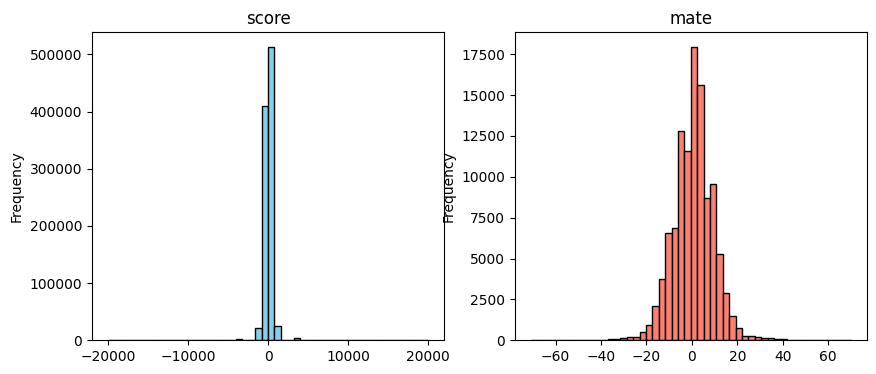

In [24]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# 2. Flatten the axes array for simple 1D indexing
axes_flat = axs.flatten()

# 3. Explicitly plot each distribution to its respective axis
df['score'].plot(kind='hist', ax=axes_flat[0], bins=50, color='skyblue', edgecolor='black', title='score')
df['mate'].plot(kind='hist', ax=axes_flat[1], bins=50, color='salmon', edgecolor='black', title='mate')

## Outcome / draw encoding
Check the value counts of `white_result` and `black_result`. How is a draw represented? What are the class proportions (win/loss/draw)?

In [26]:
df['white_result'].value_counts(sort=True, ascending=False)


white_result
1      534144
0      497170
1/2     59764
Name: count, dtype: int64

In [27]:
df['black_result'].value_counts(sort=True, ascending=False)

black_result
0      534144
1      497170
1/2     59764
Name: count, dtype: int64

## Elo columns
`white_elo`/`black_elo` loaded with an unexpected dtype. Figure out why — find the non-numeric values hiding in those columns.

In [31]:
# Find values that cannot be converted to numbers AND were not originally missing.
df['white_elo'][pd.to_numeric(df['white_elo'], errors='coerce').isna() & df['white_elo'].notna()]

248901     ?
248902     ?
248903     ?
248904     ?
248905     ?
          ..
1055751    ?
1055752    ?
1055753    ?
1055754    ?
1055755    ?
Name: white_elo, Length: 636, dtype: object

In [30]:
df['black_elo'][pd.to_numeric(df['black_elo'], errors='coerce').isna() & df['black_elo'].notna()]

4911       ?
4912       ?
4913       ?
4914       ?
4915       ?
          ..
1089222    ?
1089223    ?
1089224    ?
1089225    ?
1089226    ?
Name: black_elo, Length: 883, dtype: object

## Positions per game
We'll need this for a leakage-safe train/test split later. Group by `game_id` and find how many positions each game contributes — count of games, and the distribution (min/mean/median/max) of positions per game.

In [37]:
print('number of games:', df.groupby('game_id').size().shape[0])

print(df.groupby('game_id').size().describe())

number of games: 16643
count    16643.000000
mean        65.557772
std         32.948054
min          2.000000
25%         43.000000
50%         61.000000
75%         84.000000
max        244.000000
dtype: float64


Text(0, 0.5, 'game')

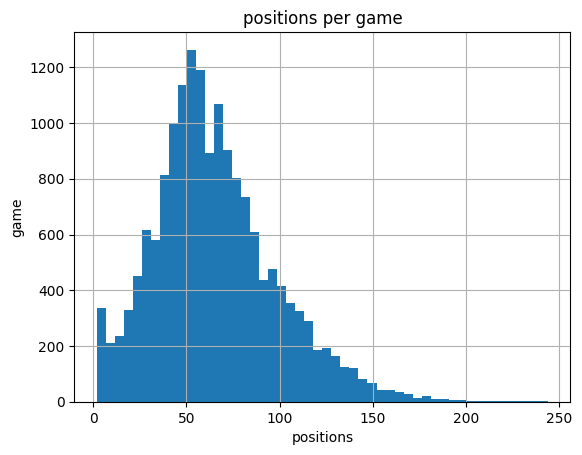

In [38]:
positions_per_game = df.groupby('game_id').size()
positions_per_game.hist(bins=50)
plt.title('positions per game')
plt.xlabel('positions')
plt.ylabel('game')